In [1]:
import numpy as np
%matplotlib inline

from devito import configuration

configuration['log-level'] = 'WARNING'

In [2]:
import scipy.io as sio
from scipy import signal
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d
from scipy.signal import correlate2d
from scipy.signal import fftconvolve
from scipy.signal import convolve
from scipy.signal import correlate
from copy import deepcopy

# Contoh membaca file .mat
#data = sio.loadmat("BG450_model.mat")
data = np.loadtxt('Model/VP0_Real.txt')
#print(data.keys())
# Misalkan velocity model ada di key tertentu, misalnya 'velocity_model':
vp = data.T/1000
vp0 = np.loadtxt('Model/VP0_Real.txt').T
vp0 = (vp0/1000)
#vp0 = gaussian_filter(vp, [30, 30]) #velocity model intial


import numpy as np
from scipy.ndimage import zoom

# Misal velocity adalah array (nz, nx) dengan resolusi 10 meter
# Kita ingin menginterpolasi ke resolusi 2.5 meter
#vp0 = zoom(vp0, zoom=1.25, order=1)  # linear interpolation


waterheight = 41

vp0[:, :waterheight] = 1.5

vp1 = deepcopy(vp0)
vp1[0, 0] = 4.7
#vp1[0,0] = 1.028

print(np.min(vp1))
print(np.max(vp1))
print(np.min(vp0))
print(np.max(vp0))

vp0.shape

1.028
4.7
1.028
4.7


(1317, 281)

In [3]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import Model, plot_velocity, plot_perturbation, Receiver

# Define a physical size
shape = (vp0.shape)  # Number of grid point (nx, nz)
spacing = (12.5, 12.5)  # Grid spacing in m. The domain size is now 1km by 1km
origin = (0.,0.)  # What is the location of the top left corner. This is necessary to define
nboundary = 160


model0 = Model(vp=vp0, origin=origin, shape=shape, spacing=spacing,
              space_order=2, nbl=nboundary, bcs="damp")


model1 = Model(vp=vp1, origin=origin, shape=shape, spacing=spacing,
              space_order=2, nbl=nboundary, bcs="damp", grid = model0.grid)

(1317, 281)


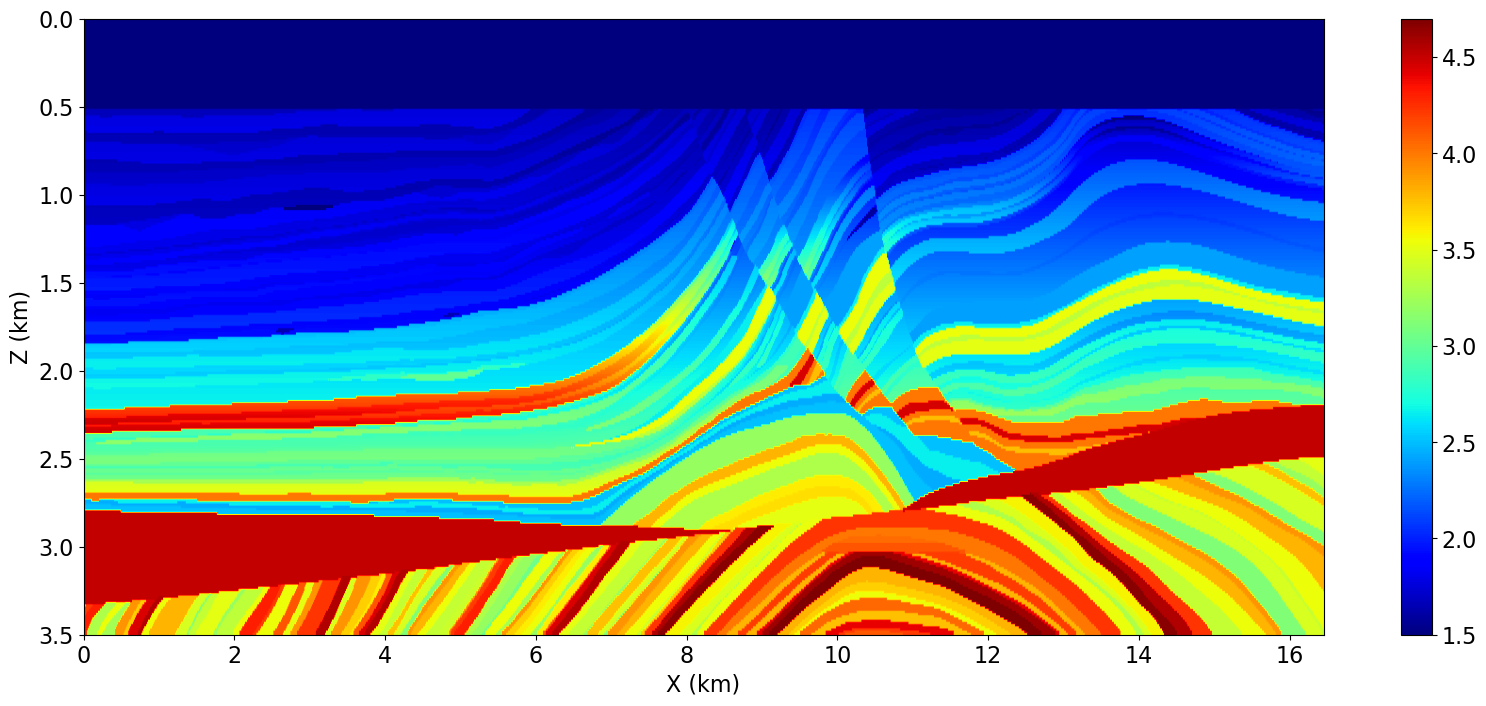

In [4]:
real_model = model0.vp.data[nboundary:-nboundary, nboundary:-nboundary]


# Cek hasilnya
print(real_model.shape)

xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=[20,8])
plt.imshow(real_model.T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.7, aspect='auto')
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

(1317, 281)


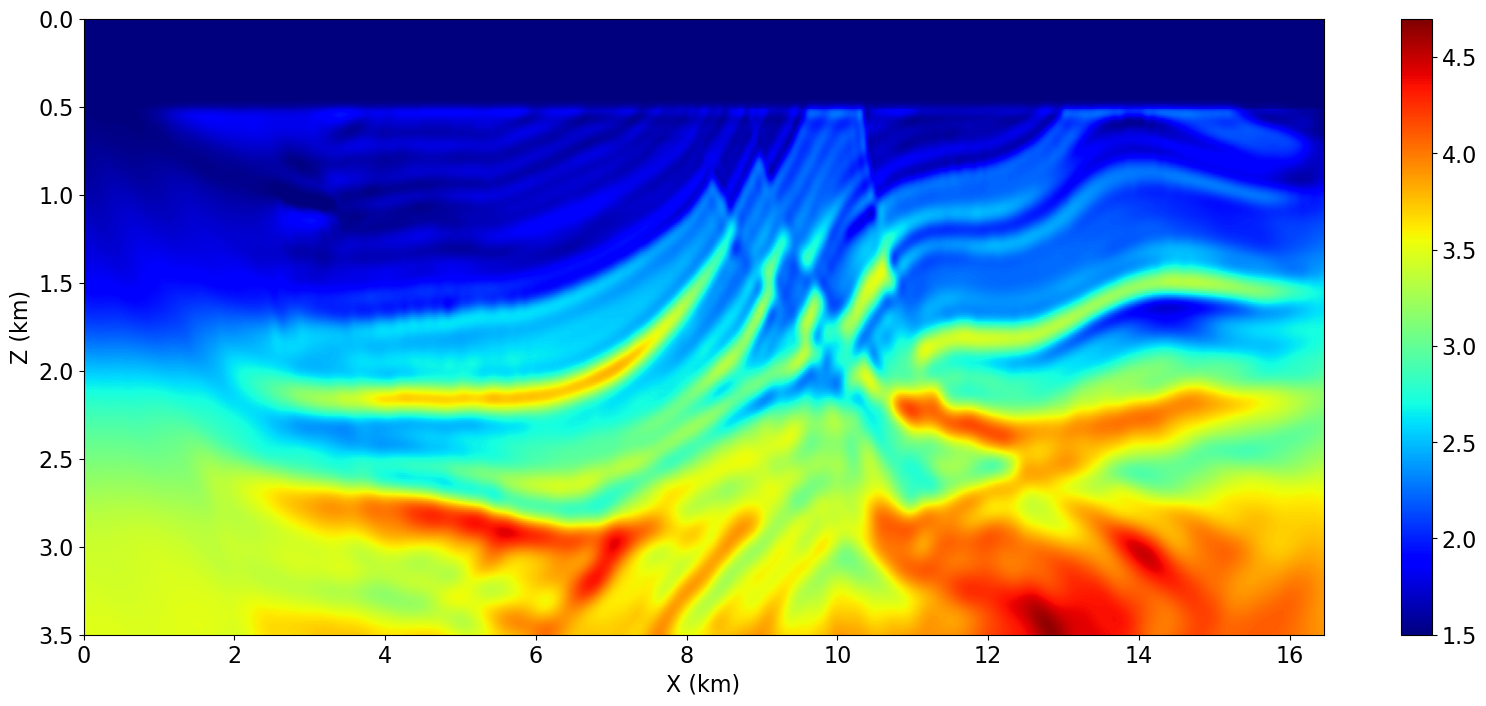

In [23]:
import numpy as np
from copy import deepcopy

model_cek = deepcopy(model0)

# Load file .npy
model_cek.vp.data[:] = np.loadtxt('Model_Progres/Best Model 6.0 Hz INVERSION.txt')

best_model_smoothed = model_cek.vp.data[nboundary:-nboundary, nboundary:-nboundary]


# Cek hasilnya
print(best_model_smoothed.shape)




xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=(20, 8))
plt.imshow(best_model_smoothed.T, extent=[xmin, xmax, zmax, zmin], cmap='jet', aspect='auto', vmin = 1.5, vmax=4.7)
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

(1317, 281)


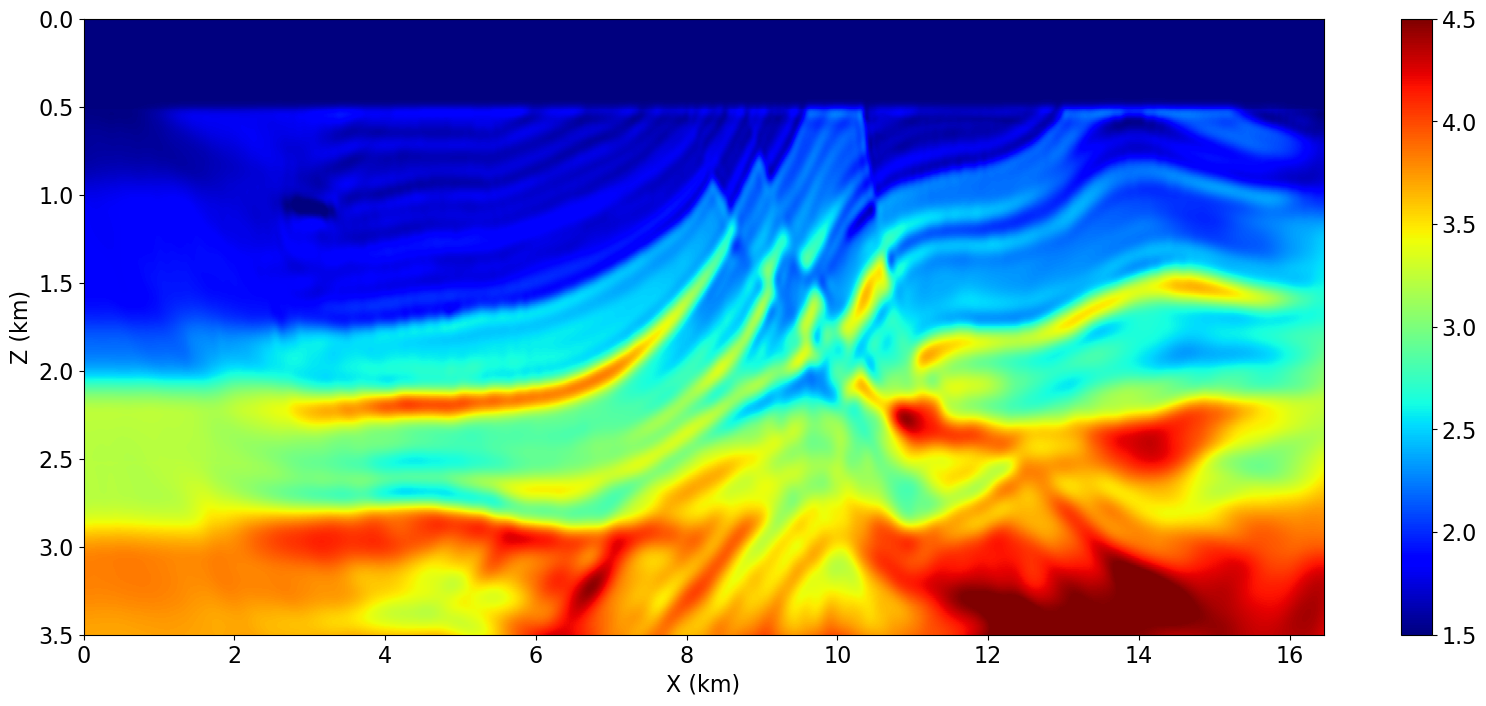

In [6]:
import numpy as np
from copy import deepcopy

model_cek = deepcopy(model0)

# Load file .npy
model_cek.vp.data[:] = np.loadtxt('Model_Progres/Best Model 8.0 Hz PROMAX.txt')

best_model_promax = model_cek.vp.data[nboundary:-nboundary, nboundary:-nboundary]


# Cek hasilnya
print(best_model_promax.shape)




xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=(20, 8))
plt.imshow(best_model_promax.T, extent=[xmin, xmax, zmax, zmin], cmap='jet', aspect='auto', vmin = 1.5, vmax=4.5)
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

(1317, 281)


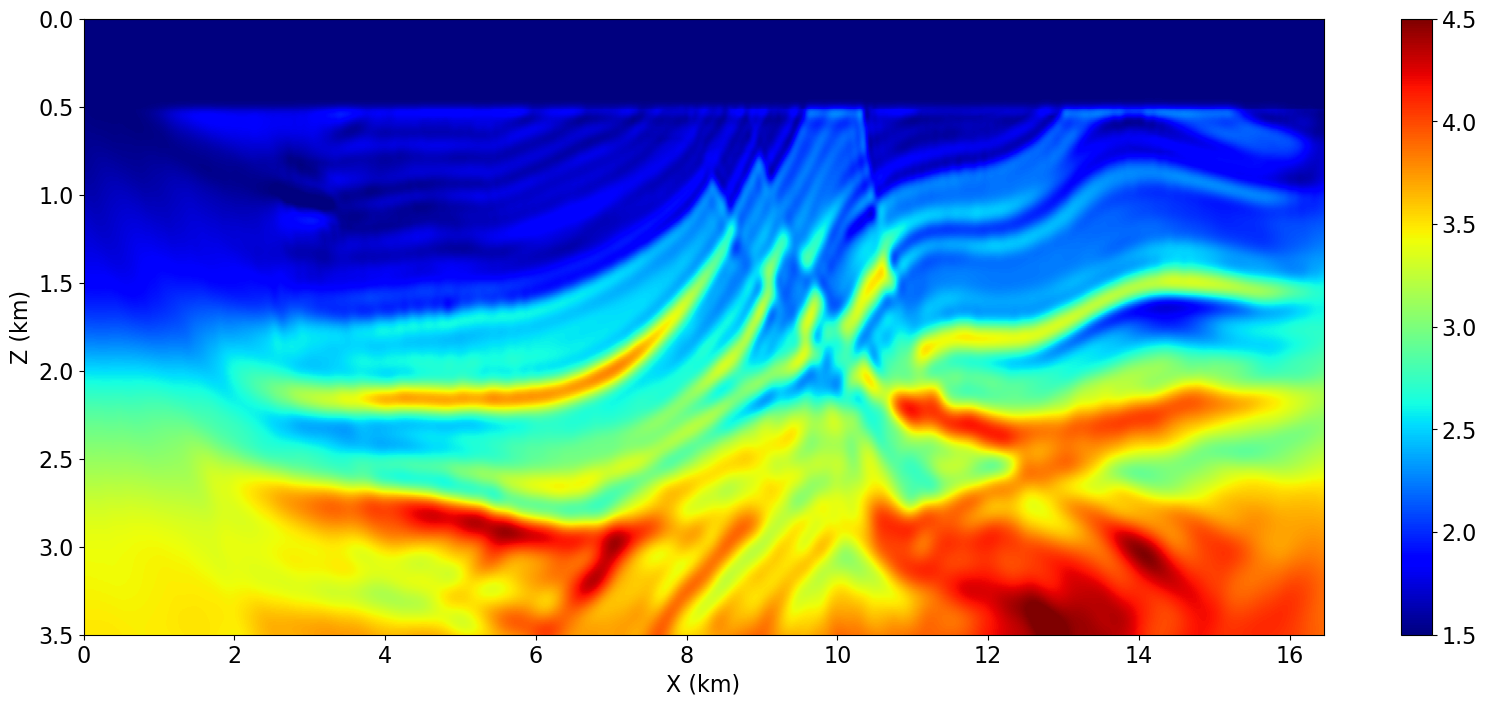

In [16]:
import numpy as np
from copy import deepcopy

model_cek = deepcopy(model0)

# Load file .npy
model_cek.vp.data[:] = np.loadtxt('Model_Progres/Best Model 6.0 Hz INVERSION.txt')

best_model_inversion = model_cek.vp.data[nboundary:-nboundary, nboundary:-nboundary]


# Cek hasilnya
print(best_model_inversion.shape)




xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=(20, 8))
plt.imshow(best_model_inversion.T, extent=[xmin, xmax, zmax, zmin], cmap='jet', aspect='auto', vmin = 1.5, vmax=4.5)
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

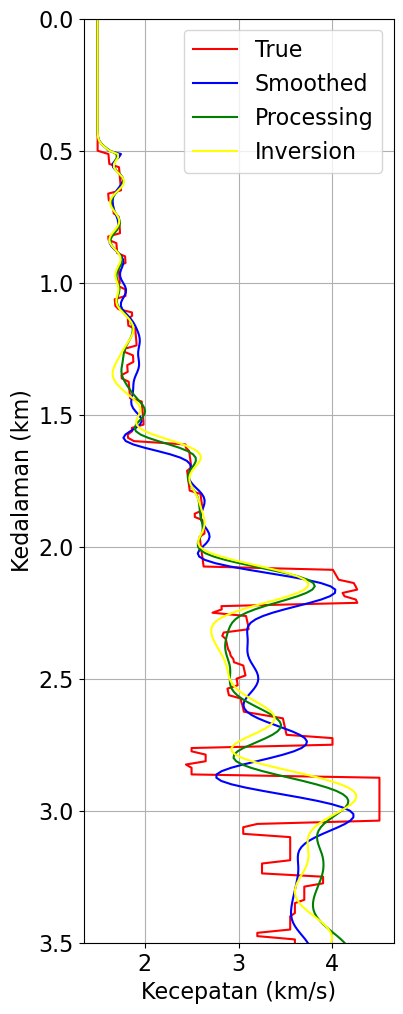

In [9]:
velocity_smoothed = best_model_smoothed[481,:]
velocity_promax = best_model_promax[481,:]
velocity_inversion = best_model_inversion[481,:]
velocity_real = real_model[481,:]
DEPTH = np.arange(281)*0.0125


plt.figure(figsize=(4, 12))
plt.plot(velocity_real, DEPTH, color='red', label="True")
plt.plot(velocity_smoothed, DEPTH, color='blue', label="Smoothed")
plt.plot(velocity_promax, DEPTH, color='green', label="Processing")
plt.plot(velocity_inversion, DEPTH, color='yellow', label="Inversion")
plt.gca().invert_yaxis()  # Membalik sumbu Y agar kedalaman meningkat ke bawah
plt.xlabel('Kecepatan (km/s)')
plt.ylabel('Kedalaman (km)')
plt.ylim(3.5,0)
#plt.title('Profil Kecepatan (X : 14 km)')
plt.grid(True)
#plt.tight_layout()
plt.legend()
plt.show()

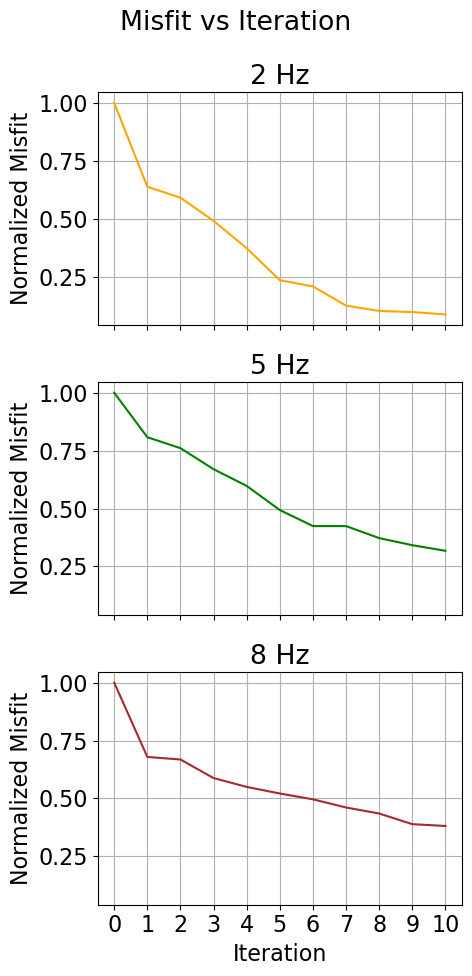

In [41]:
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import numpy as np


misfit_freq_2 = np.loadtxt(f'Model_Progres/Misfit 2.0 Hz Smoothed.txt')
misfit_freq_6 = np.loadtxt(f'Model_Progres/Misfit 5.0 Hz Smoothed.txt')
misfit_freq_10 = np.loadtxt(f'Model_Progres/Misfit 8.0 Hz Smoothed.txt')

normalized_misfit_freq_2 = misfit_freq_2/misfit_freq_2[0]
normalized_misfit_freq_6 = misfit_freq_6/misfit_freq_6[0]
normalized_misfit_freq_10 = misfit_freq_10/misfit_freq_10[0]
all_normalized_misfit = np.concatenate((normalized_misfit_freq_2, normalized_misfit_freq_6, normalized_misfit_freq_10))

# Misal datanya sudah distandarkan
iter_reset = list(range(11))  # 0–10

fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharey=True, sharex=True)

axs[0].plot(iter_reset, normalized_misfit_freq_2, color='orange')
axs[0].set_title('2 Hz')
axs[0].set_ylabel('Normalized Misfit')
axs[0].set_xticks(range(11))
axs[0].grid(True)

axs[1].plot(iter_reset, normalized_misfit_freq_6, color='green')
axs[1].set_title('5 Hz')
#axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Normalized Misfit')
axs[1].set_xticks(range(11))
axs[1].grid(True)

axs[2].plot(iter_reset, normalized_misfit_freq_10, color='brown')
axs[2].set_title('8 Hz')
#axs[2].set_xlabel('Iteration')
axs[2].set_xlabel('Iteration')
axs[2].set_ylabel('Normalized Misfit')
axs[2].set_xticks(range(11))
axs[2].grid(True)

plt.suptitle('Misfit vs Iteration')
plt.tight_layout()
plt.show()

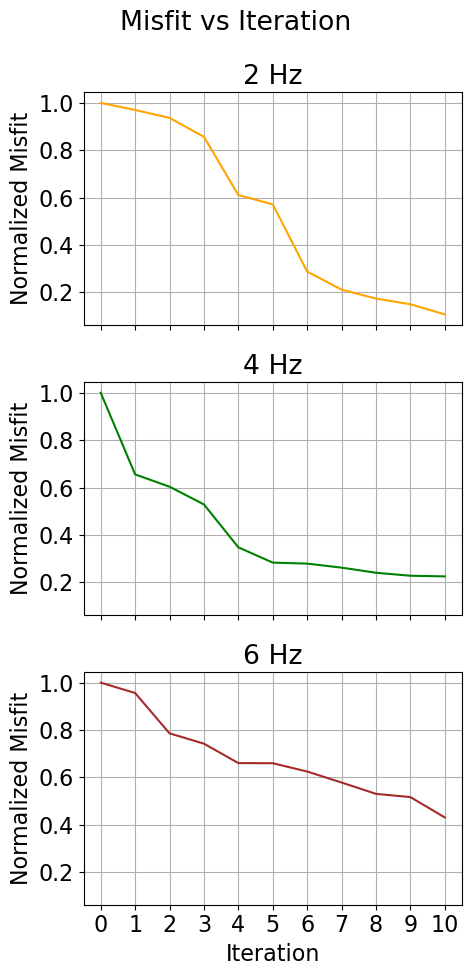

In [10]:
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import numpy as np


misfit_freq_2 = np.loadtxt(f'Model_Progres/Misfit 2.0 Hz INVERSION.txt')
misfit_freq_6 = np.loadtxt(f'Model_Progres/Misfit 4.0 Hz INVERSION.txt')
misfit_freq_10 = np.loadtxt(f'Model_Progres/Misfit 6.0 Hz INVERSION.txt')

normalized_misfit_freq_2 = misfit_freq_2/misfit_freq_2[0]
normalized_misfit_freq_6 = misfit_freq_6/misfit_freq_6[0]
normalized_misfit_freq_10 = misfit_freq_10/misfit_freq_10[0]
all_normalized_misfit = np.concatenate((normalized_misfit_freq_2, normalized_misfit_freq_6, normalized_misfit_freq_10))

# Misal datanya sudah distandarkan
iter_reset = list(range(11))  # 0–10

fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharey=True, sharex=True)

axs[0].plot(iter_reset, normalized_misfit_freq_2, color='orange')
axs[0].set_title('2 Hz')
axs[0].set_ylabel('Normalized Misfit')
axs[0].set_xticks(range(11))
axs[0].grid(True)

axs[1].plot(iter_reset, normalized_misfit_freq_6, color='green')
axs[1].set_title('4 Hz')
#axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Normalized Misfit')
axs[1].set_xticks(range(11))
axs[1].grid(True)

axs[2].plot(iter_reset, normalized_misfit_freq_10, color='brown')
axs[2].set_title('6 Hz')
#axs[2].set_xlabel('Iteration')
axs[2].set_xlabel('Iteration')
axs[2].set_ylabel('Normalized Misfit')
axs[2].set_xticks(range(11))
axs[2].grid(True)

plt.suptitle('Misfit vs Iteration')
plt.tight_layout()
plt.show()

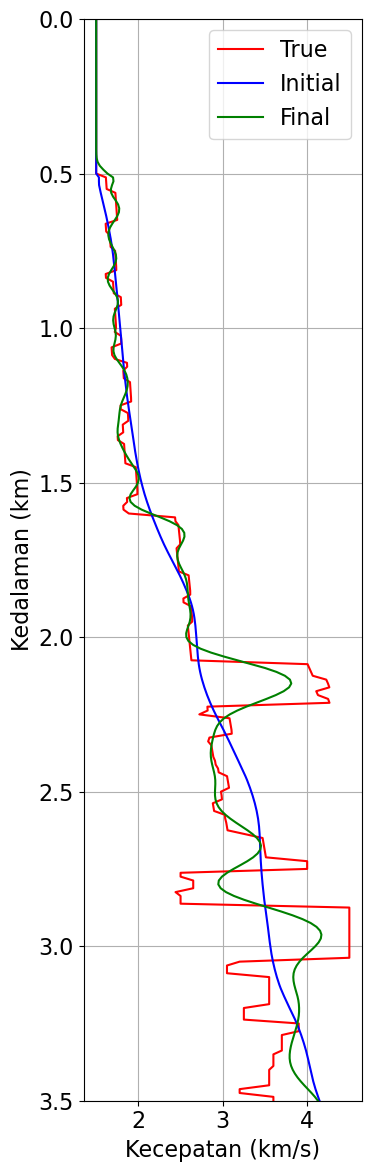

In [71]:
x_loc = 481

velocity_smoothed = best_model_smoothed[x_loc,:]
velocity_promax = best_model_promax[x_loc,:]
velocity_real = real_model[x_loc,:]
velocity_initial_smoothed = initial_model[x_loc,:]
velocity_initial_promax = initial_model_promax[x_loc,:]
DEPTH = np.arange(281)*0.0125


plt.figure(figsize=(4, 12))
plt.plot(velocity_real, DEPTH, color='red', label="True")
plt.plot(velocity_initial_promax, DEPTH, color='blue', label="Initial")
plt.plot(velocity_promax, DEPTH, color='green', label="Final")
plt.gca().invert_yaxis()  # Membalik sumbu Y agar kedalaman meningkat ke bawah
plt.xlabel('Kecepatan (km/s)')
plt.ylabel('Kedalaman (km)')
#plt.title('Profil Kecepatan di 10 km')
plt.ylim(3.5,0)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [17]:
final_velocity_smoothed = best_model_smoothed[165:,:]*1000
final_velocity_promax = best_model_promax[165:,:]*1000
final_velocity_inversion = best_model_inversion[165:,:]*1000
true_velocity = real_model[165:,:]*1000

print(final_velocity_smoothed.shape)
print(np.min(final_velocity_inversion))
print(np.max(final_velocity_inversion))

(1152, 281)
1500.0
4646.0654


In [19]:
n_depth = final_velocity_smoothed.shape[1]
n_cdp = final_velocity_smoothed.shape[0]

vel_int = final_velocity_inversion.T

depths = np.arange(n_depth)*12.5

filename = 'Final_FWI_Inversion.txt'

with open(filename, 'w') as f:
    f.write("CDP  Depth   VEL_INT  Y_loc\n")
    for j in range(n_cdp):
        for i in range(n_depth):
            cdp = j + 1
            depth = depths[i]
            velocity = vel_int[i, j]
            y_loc = 0
            f.write(f"{cdp:4.0f} {depth:6.1f}   {velocity:8.2f}     {y_loc}\n")

In [31]:
import numpy as np
import segyio
import os

# === Asumsi model kecepatan tersedia ===
# velocity_model: shape = (n_cdp, n_depth)
velocity_model = final_velocity_smoothed.T  # Transpose jadi (n_depth, n_cdp)
n_depth, n_cdp = velocity_model.shape

dz = 12.5  # Interval kedalaman (meter)
samples = np.arange(0, n_depth * dz, dz)  # Sumbu sample

output_file = "FWI_from_Smoothed_TrueModel.sgy"

# Hapus file jika sudah ada
if os.path.exists(output_file):
    os.remove(output_file)

# Setup spec segyio
spec = segyio.spec()
spec.sorting = 1  # CDP ordered
spec.format = 5   # IEEE floating point
spec.samples = samples
spec.tracecount = n_cdp

with segyio.create(output_file, spec) as f:
    for i in range(n_cdp):
        f.trace[i] = velocity_model[:, i].astype(np.float32)

        # Header minimal
        f.header[i] = {
            segyio.TraceField.TRACE_SEQUENCE_LINE: i + 1,
            segyio.TraceField.CDP: i + 1,
            segyio.TraceField.TRACE_SEQUENCE_LINE: int(i + 1),
            segyio.TraceField.TRACE_SEQUENCE_FILE: int(i + 1),
            segyio.TraceField.TraceNumber: int(i + 1),
            segyio.TraceField.ReceiverGroupElevation: int(0),
            segyio.TraceField.SourceSurfaceElevation: int(0),
            segyio.TraceField.SourceDepth: int(0),
            segyio.TraceField.SourceX: int((i+165)*12.5*1000),
            segyio.TraceField.SourceY: int(0),
            segyio.TraceField.GroupX: int((i+165)*12.5*1000),
            segyio.TraceField.GroupY: int(0),
            segyio.TraceField.TRACE_SAMPLE_COUNT : n_depth,
            segyio.TraceField.TRACE_SAMPLE_INTERVAL : 12500,
            segyio.TraceField.CDP_X : int((i+165)*12.5*1000),
            segyio.TraceField.CDP_Y : 0
        }

print(f"✅ File SEG-Y model kecepatan berhasil dibuat: {output_file}")


✅ File SEG-Y model kecepatan berhasil dibuat: FWI_from_Smoothed_TrueModel.sgy


In [33]:
import segyio
import numpy as np

import scipy.io as sio
from scipy import signal
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d
from scipy.signal import correlate2d
from scipy.signal import fftconvolve
from scipy.signal import convolve
from scipy.signal import correlate


# Path file segy
filename = 'Model/vel_postinversion.segy'

with segyio.open(filename, "r", ignore_geometry=True) as f:
    f.mmap()  # memory map untuk performa
    n_traces = f.tracecount
    n_samples = f.samples.size

    # Inisialisasi array (n_samples, n_traces) = (depth, lateral)
    velocity = np.zeros((n_samples, n_traces))

    # Baca trace satu per satu
    for i in range(n_traces):
        velocity[:, i] = f.trace[i]

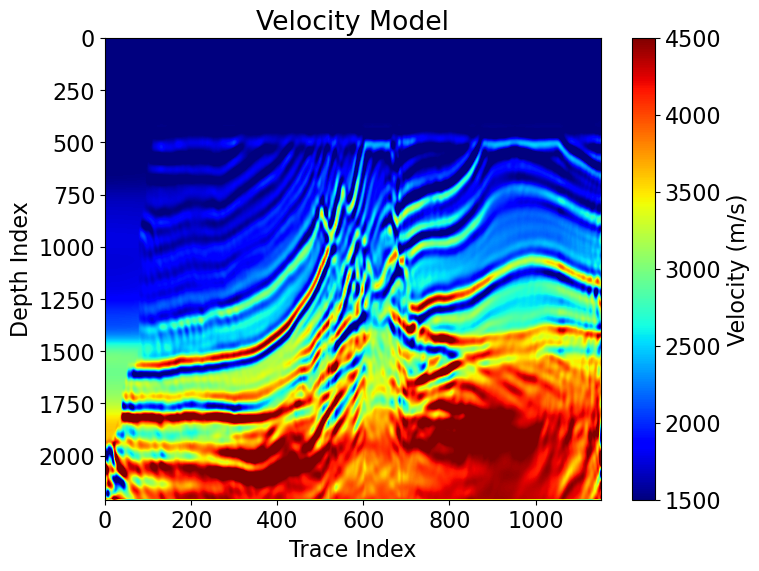

In [34]:
import matplotlib.pyplot as plt

plt.imshow(velocity, cmap='jet', aspect='auto', origin='upper', vmin=1500, vmax=4500)
plt.colorbar(label='Velocity (m/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()

In [41]:
vel_clip = np.clip(velocity, 1500, 4700)

In [44]:
np.min(vel_clip)

1500.0

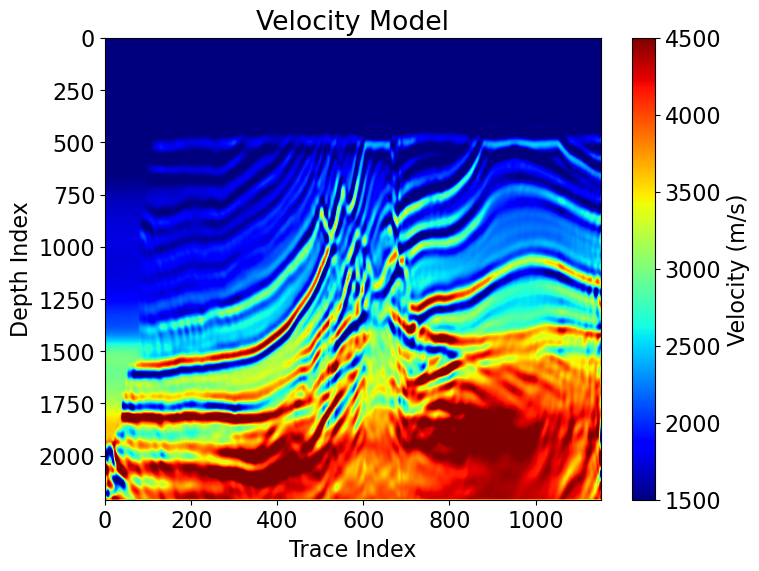

In [51]:
import matplotlib.pyplot as plt

plt.imshow(vel_clip, cmap='jet', aspect='auto', origin='upper', vmin=1500, vmax=4500)
plt.colorbar(label='Velocity (m/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()

In [52]:
vel_clip.shape

(2211, 1152)

In [53]:
n_time = vel_clip.shape[0]
n_cdp = vel_clip.shape[1]

vel_int = vel_clip

times = np.arange(n_time)*1.629

filename = 'Poststack_inversion.txt'

with open(filename, 'w') as f:
    f.write("CDP  Time   VEL_INT  Y_loc\n")
    for j in range(n_cdp):
        for i in range(n_time):
            cdp = j + 1
            time_i = times[i]
            velocity = vel_int[i, j]
            y_loc = 0
            f.write(f"{cdp:4.0f} {time_i:6.1f}   {velocity:8.2f}     {y_loc}\n")

In [49]:
2210*1.629

3600.09